In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

In [31]:
df = pd.read_csv("../Dataset/insurance.csv")

In [32]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [33]:
df.shape

(1338, 7)

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [35]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [36]:
# Checking null values in the dataset
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [37]:
# Cheching Duplicate vales 
df.duplicated().sum()

np.int64(1)

In [38]:
# 1 Duplicate exist, removing it
df = df.drop_duplicates()

In [39]:
# Age, BMI, charges can never be negative so checking it
(df["age"] <= 0).sum()

(df["bmi"] <= 0).sum()

(df["charges"] <= 0).sum()

np.int64(0)

In [40]:
# Making every text standardizes so that the comp can understand it
# Last step of data cleaning
df["sex"] = df["sex"].str.lower().str.strip()

df["smoker"] = df["smoker"].str.lower().str.strip()

df["region"] = df["region"].str.lower().str.strip()

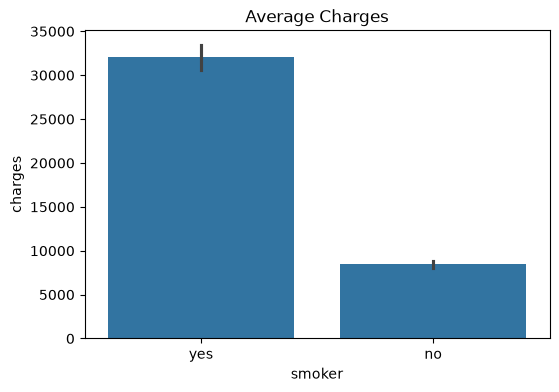

In [41]:
# Exploratory Data Analysis
# Bar Graph (Smoker vs Charges)
plt.figure(figsize=(6,4))

sns.barplot(data=df,
            x="smoker",
            y="charges")

plt.title("Average Charges")
plt.show()

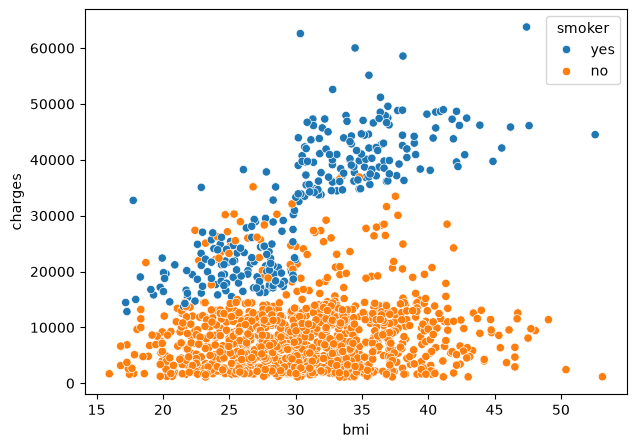

In [42]:
# Scatter Plot
# BMI vs Charges
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker"
)

plt.show()

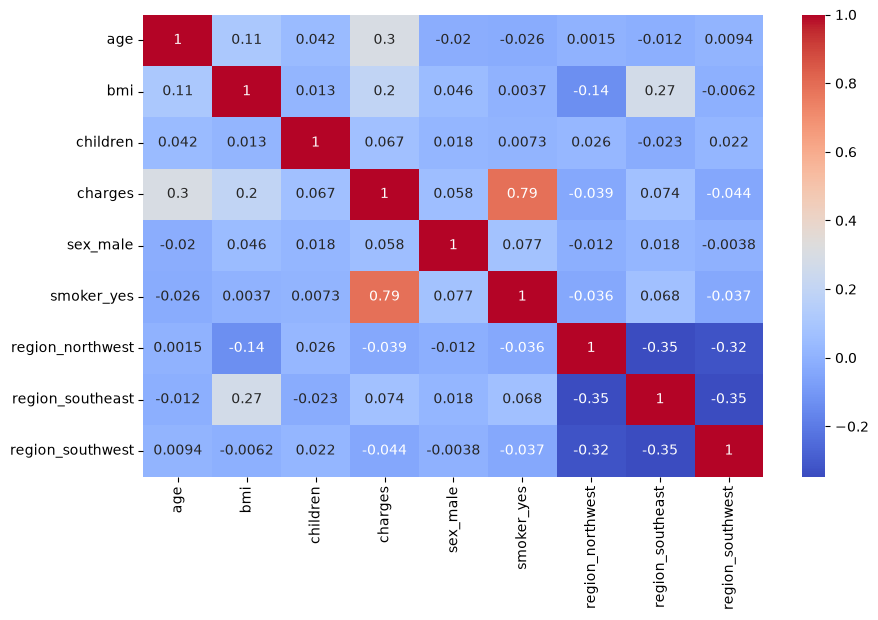

In [43]:
# Heatmap
# Shows correlation between variables
temp = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(10,6))

sns.heatmap(temp.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()


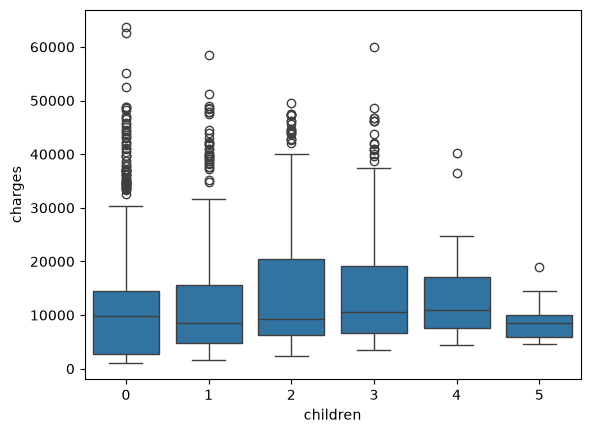

In [44]:
# Box plot
# Children vs Charges
sns.boxplot(
    data=df,
    x="children",
    y="charges"
)

plt.show()

In [45]:
# Feature Engineering
# One-Hot Encoding (Only 2 variables)
df = pd.get_dummies(
    df,
    columns=["sex","smoker","region"],
    drop_first=True
)

In [46]:
def bmi_category(x):

    if x < 18.5:
        return "Underweight"

    elif x < 25:
        return "Normal"

    elif x < 30:
        return "Overweight"

    else:
        return "Obese"

In [47]:
df["bmi_category"] = df["bmi"].apply(bmi_category)

In [48]:
# Encode it
df = pd.get_dummies(
    df,
    columns=["bmi_category"],
    drop_first=True
)

In [49]:
# Helps model understand that BMI has a much stronger effect for smokers.
df["smoker_bmi"] = (
    df["smoker_yes"] * df["bmi"]
)

In [50]:
#Separate Features
X = df.drop("charges", axis=1)

y = df["charges"]

In [51]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [52]:
# Train Model
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ 258.67, -210.88, 572.28,..., -223.89,-1084.64, 1477.4 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['age','bmi','children',...,'bmi_category_Overweight', 'bmi_category_Underweight','smoker_bmi']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3424
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,12


In [53]:
# Predictions
y_pred = model.predict(X_test)

In [54]:
# Evaluation R2 Score
print("R2 :", r2_score(y_test, y_pred))


R2 : 0.8868141245573691


In [55]:
# Checking error
print("MAE :", mean_absolute_error(y_test, y_pred))

MAE : 2813.0707550847505


In [56]:
print("RMSE :", root_mean_squared_error(y_test, y_pred))

RMSE : 4560.547223347653


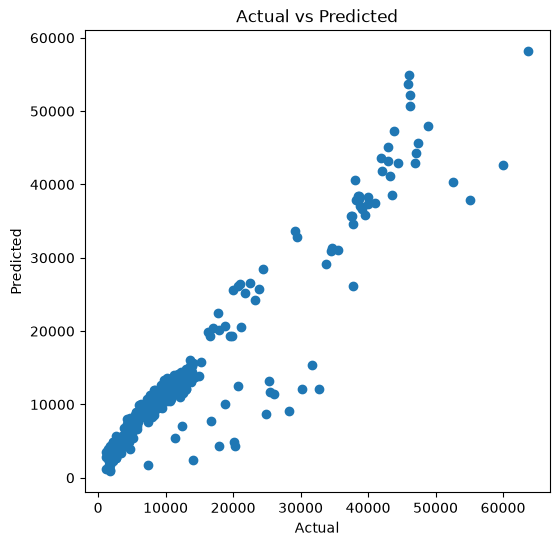

In [57]:
# Actual vs Predicted Plot
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

In [58]:
# Feature Importance
importance = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":model.coef_

})

importance = importance.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

importance

,Feature,Coefficient
4,smoker_yes,-21728.495926
8,bmi_category_Obese,3168.582416
11,smoker_bmi,1477.400199
10,bmi_category_Underweight,-1084.641765
7,region_southwest,-970.042436
6,region_southeast,-742.657188
3,sex_male,-630.649153
2,children,572.280181
5,region_northwest,-476.627136
0,age,258.674651
